<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/18_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ARTIFICIAL NEURAL NETWORKS**

##**Case Study: SONAR — Detecting Mines vs. Rocks**

**Data Preparation**

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv("sonardataset.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nTarget Classes:")
print(df["Y"].value_counts())

Dataset Shape: (208, 61)

First 5 Rows:
      x_1     x_2     x_3     x_4     x_5     x_6     x_7     x_8     x_9  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

     x_10  ...    x_52    x_53    x_54    x_55    x_56    x_57    x_58  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

     x_59    x_60  Y  
0  0.0090  0.0032  R  
1  0.0

**Data Exploration and Preprocessing**

In [ ]:

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nNumber of Features:", df.shape[1] - 1)
print("Number of Samples:", df.shape[0])
print("Number of Classes:", df["Y"].nunique())

X = df.drop(columns=["Y"]).copy()
y = df["Y"].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nClasses:", label_encoder.classes_)
print("Missing Values After Handling:", X.isnull().sum().sum())

Missing Values:
x_1     0
x_2     0
x_3     0
x_4     0
x_5     0
       ..
x_57    0
x_58    0
x_59    0
x_60    0
Y       0
Length: 61, dtype: int64

Duplicate Rows: 0

Number of Features: 60
Number of Samples: 208
Number of Classes: 2

Classes: ['M' 'R']
Missing Values After Handling: 0


**Data Visualization**

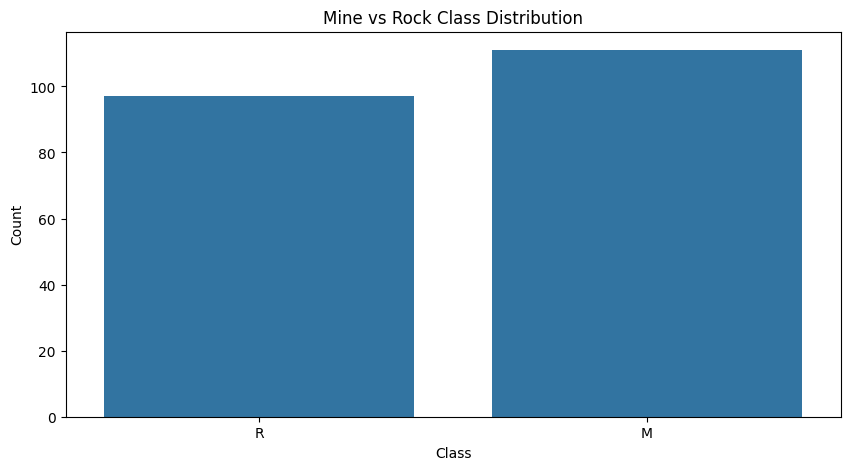

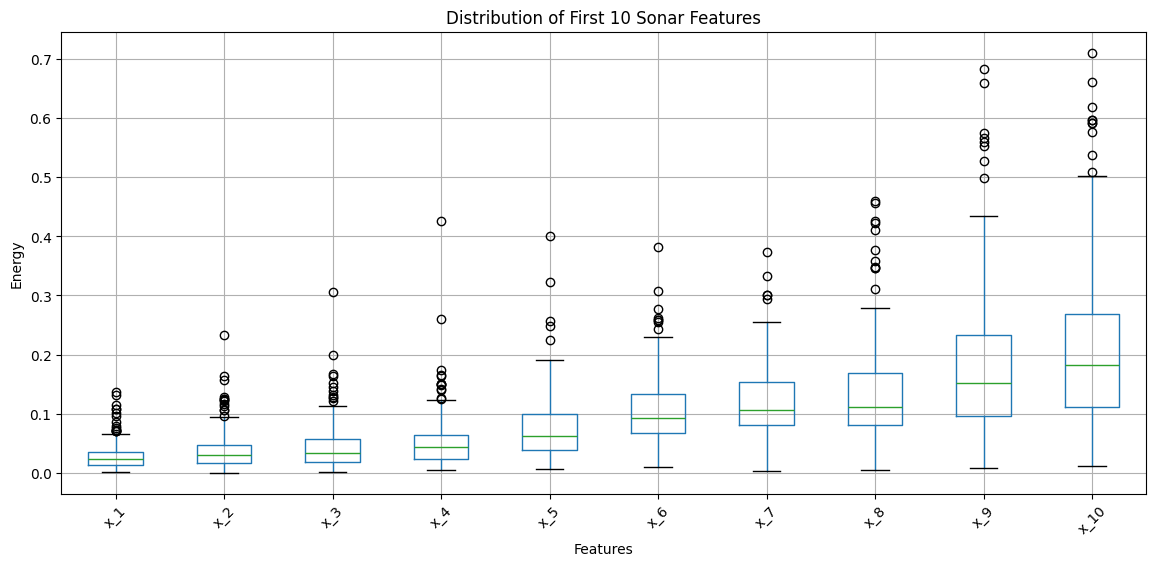

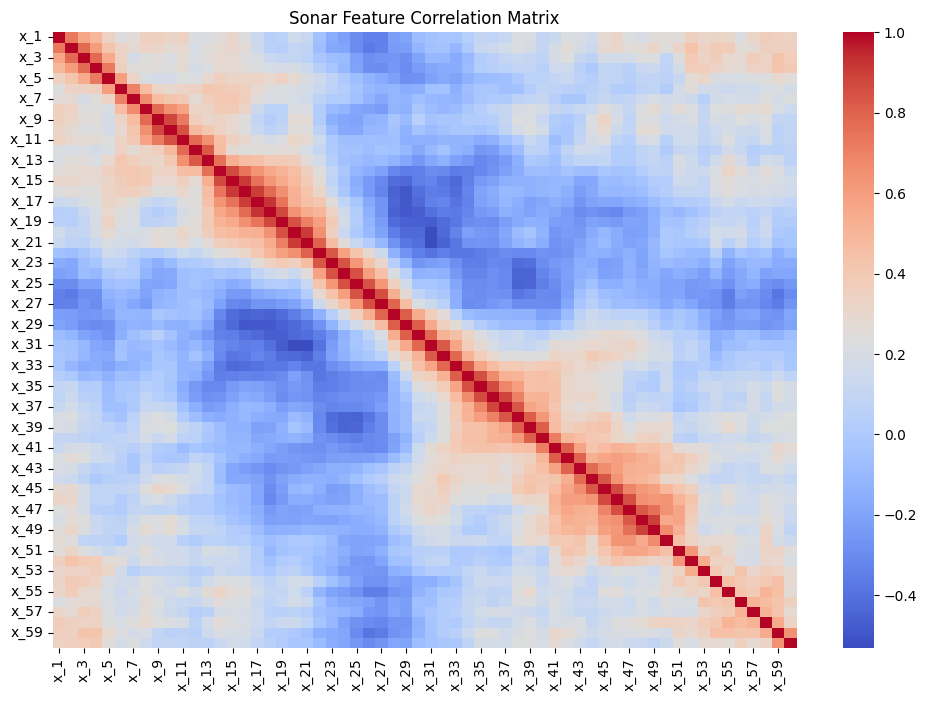

In [ ]:

plt.figure(figsize=(10, 5))
sns.countplot(x=y)
plt.title("Mine vs Rock Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(14, 6))
X.iloc[:, :10].boxplot()
plt.title("Distribution of First 10 Sonar Features")
plt.xlabel("Features")
plt.ylabel("Energy")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Sonar Feature Correlation Matrix")
plt.show()

**Train Test Split and Normalization**

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Samples:", X_train_scaled.shape[0])
print("Testing Samples:", X_test_scaled.shape[0])
print("Number of Features:", X_train_scaled.shape[1])

Training Samples: 166
Testing Samples: 42
Number of Features: 60


**Basic ANN Model**

In [ ]:

basic_ann = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

basic_ann.fit(X_train_scaled, y_train)

basic_pred = basic_ann.predict(X_test_scaled)

print("Basic ANN Accuracy:", accuracy_score(y_test, basic_pred))
print("Basic ANN Precision:", precision_score(y_test, basic_pred, zero_division=0))
print("Basic ANN Recall:", recall_score(y_test, basic_pred, zero_division=0))
print("Basic ANN F1-Score:", f1_score(y_test, basic_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test,
    basic_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

Basic ANN Accuracy: 0.8333333333333334
Basic ANN Precision: 0.8823529411764706
Basic ANN Recall: 0.75
Basic ANN F1-Score: 0.8108108108108109

Classification Report:
              precision    recall  f1-score   support

           M       0.80      0.91      0.85        22
           R       0.88      0.75      0.81        20

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.83        42
weighted avg       0.84      0.83      0.83        42



**Hyperparameter Tuning**

In [ ]:

parameter_grid = {
    "hidden_layer_sizes": [(8,), (16,), (32,), (16, 8), (32, 16)],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01],
    "alpha": [0.0001, 0.001]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    MLPClassifier(
        max_iter=1000,
        random_state=42
    ),
    parameter_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(grid_search.best_score_)

Best Parameters:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.01}

Best Cross-Validation F1-Score:
0.8012034739454095


**Tuned ANN Evaluation**

In [ ]:

tuned_ann = grid_search.best_estimator_

tuned_pred = tuned_ann.predict(X_test_scaled)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred, zero_division=0)
tuned_recall = recall_score(y_test, tuned_pred, zero_division=0)
tuned_f1 = f1_score(y_test, tuned_pred, zero_division=0)

print("Tuned ANN Accuracy:", tuned_accuracy)
print("Tuned ANN Precision:", tuned_precision)
print("Tuned ANN Recall:", tuned_recall)
print("Tuned ANN F1-Score:", tuned_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    tuned_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

Tuned ANN Accuracy: 0.8809523809523809
Tuned ANN Precision: 0.9411764705882353
Tuned ANN Recall: 0.8
Tuned ANN F1-Score: 0.8648648648648649

Classification Report:
              precision    recall  f1-score   support

           M       0.84      0.95      0.89        22
           R       0.94      0.80      0.86        20

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42



**Confusion Matrix**

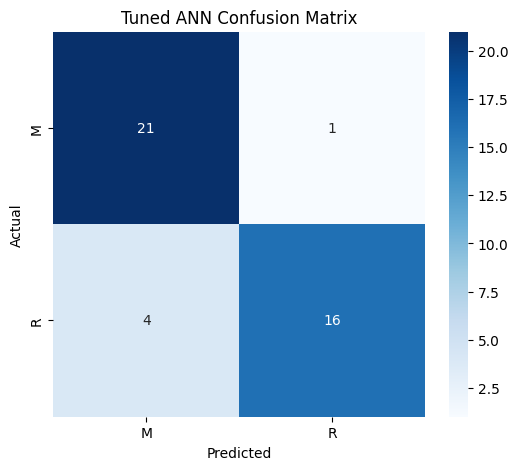

In [ ]:

cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned ANN Confusion Matrix")
plt.show()

**Training Loss Analysis**

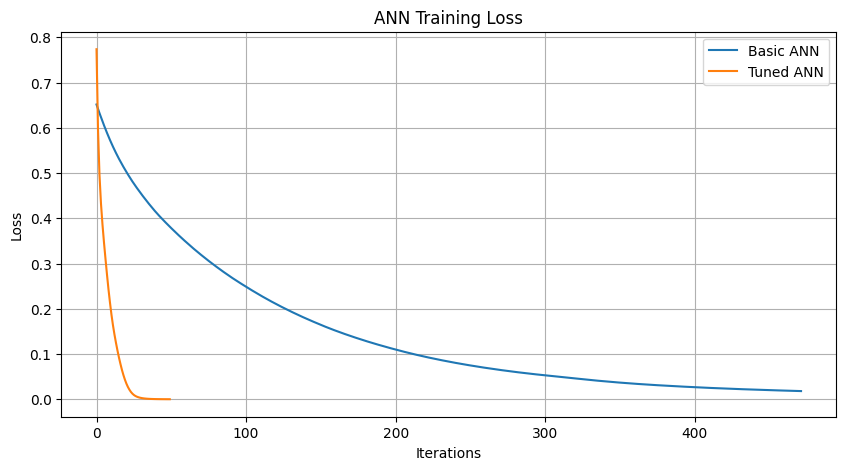

In [ ]:

plt.figure(figsize=(10, 5))
plt.plot(basic_ann.loss_curve_, label="Basic ANN")
plt.plot(tuned_ann.loss_curve_, label="Tuned ANN")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("ANN Training Loss")
plt.legend()
plt.grid()
plt.show()

**Default vs Tuned Comparison**

       Model  Accuracy  Precision  Recall  F1-Score
0  Basic ANN  0.833333   0.882353    0.75  0.810811
1  Tuned ANN  0.880952   0.941176    0.80  0.864865


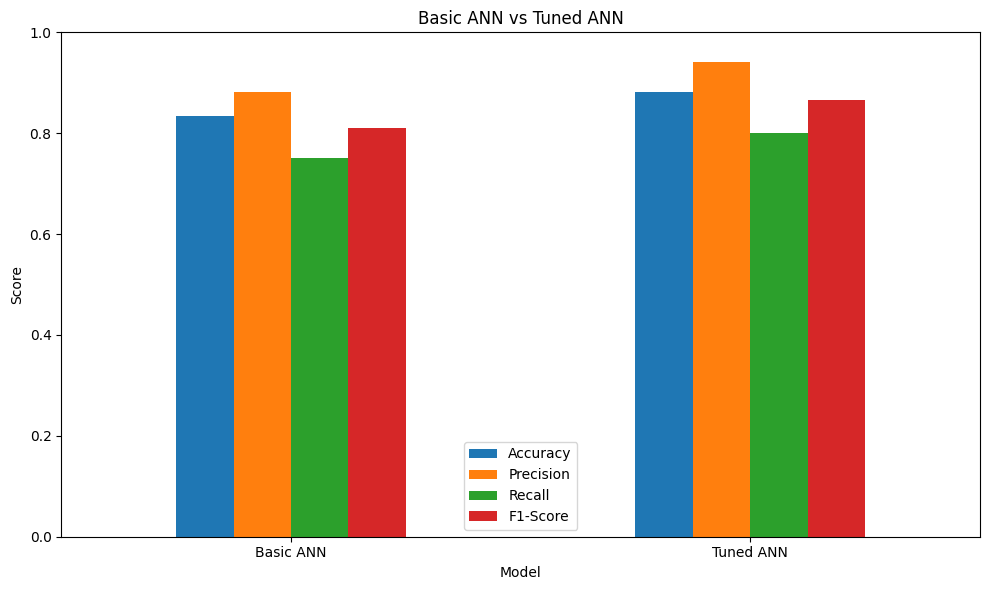

In [ ]:

comparison = pd.DataFrame({
    "Model": ["Basic ANN", "Tuned ANN"],
    "Accuracy": [
        accuracy_score(y_test, basic_pred),
        tuned_accuracy
    ],
    "Precision": [
        precision_score(y_test, basic_pred, zero_division=0),
        tuned_precision
    ],
    "Recall": [
        recall_score(y_test, basic_pred, zero_division=0),
        tuned_recall
    ],
    "F1-Score": [
        f1_score(y_test, basic_pred, zero_division=0),
        tuned_f1
    ]
})

print(comparison)

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Basic ANN vs Tuned ANN")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##**Hyperparameter Tuning Analysis**
* The basic ANN provides a baseline for model performance. The tuned ANN uses systematic Grid Search with cross-validation to test different numbers of hidden layers, neurons, activation functions, learning rates, and regularization values.

* Hyperparameter tuning can improve model performance by selecting a better network architecture and training configuration. The final comparison should be based on the actual accuracy, precision, recall, and F1-score obtained on the test set.

* The assignment specifically requires changing hidden layers, neurons, activation functions, and learning rate and using a structured search such as Grid Search or Random Search.

##**Conclusion**

* The ANN learns patterns in the 60 sonar frequency-band features to classify sonar signals as Mine (M) or Rock (R). The tuned ANN should be compared with the basic ANN using accuracy, precision, recall, and F1-score.

* A better tuned model is the one that provides stronger test-set performance while maintaining good generalization. The results should be interpreted carefully because the dataset contains only 208 samples. The original dataset description also reports that performance can vary depending on how training and testing samples are divided.

* This version covers the assignment's required preprocessing, ANN implementation, train/test prediction, systematic hyperparameter tuning, evaluation, and comparison.